<a href="https://colab.research.google.com/github/jobayer360s/Computer-Vision-and-Pattern-Recognition/blob/main/CNN_23_50647_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Liberies

1. Importing Liberies

In [84]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


2. Load and Explore Dataset

In [85]:
import kagglehub
path = kagglehub.dataset_download("nikhilgurav21/nail-disease-detection-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nail-disease-detection-dataset' dataset.
Path to dataset files: /kaggle/input/nail-disease-detection-dataset


In [86]:
import os

print(path)
print(os.listdir(path))
print(os.listdir(os.path.join(path, "data")))

/kaggle/input/nail-disease-detection-dataset
['data']
['validation', 'train']


**3. Data preprocessing and Augmentation**

In [87]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

size = 128

train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

train_folder = '/kaggle/input/nail-disease-detection-dataset/data/train'

# Base dataset (no transform)
base_dataset = datasets.ImageFolder(train_folder)

# Stratified split
indices = list(range(len(base_dataset)))
targets = base_dataset.targets

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.1,
    stratify=targets,
    random_state=42
)

# Separate datasets with different transforms
train_dataset = datasets.ImageFolder(train_folder, transform=train_transform)
val_dataset = datasets.ImageFolder(train_folder, transform=val_transform)

train_data = Subset(train_dataset, train_idx)
test_data = Subset(val_dataset, val_idx)

**4. Define CNN arch**

In [89]:
print("Train images:", len(train_data))
print("Validation images:", len(test_data))

print(train_dataset.classes)

Train images: 3369
Validation images: 375
['Acral_Lentiginous_Melanoma', 'Healthy_Nail', 'Onychogryphosis', 'blue_finger', 'clubbing', 'pitting']


In [91]:
from collections import Counter

train_targets = [base_dataset.targets[i] for i in train_idx]
val_targets = [base_dataset.targets[i] for i in val_idx]

print("Train Distribution")
print(Counter(train_targets))

print("\nValidation Distribution")
print(Counter(val_targets))

Train Distribution
Counter({4: 690, 0: 661, 2: 609, 5: 575, 3: 543, 1: 291})

Validation Distribution
Counter({4: 77, 0: 74, 2: 68, 5: 64, 3: 60, 1: 32})


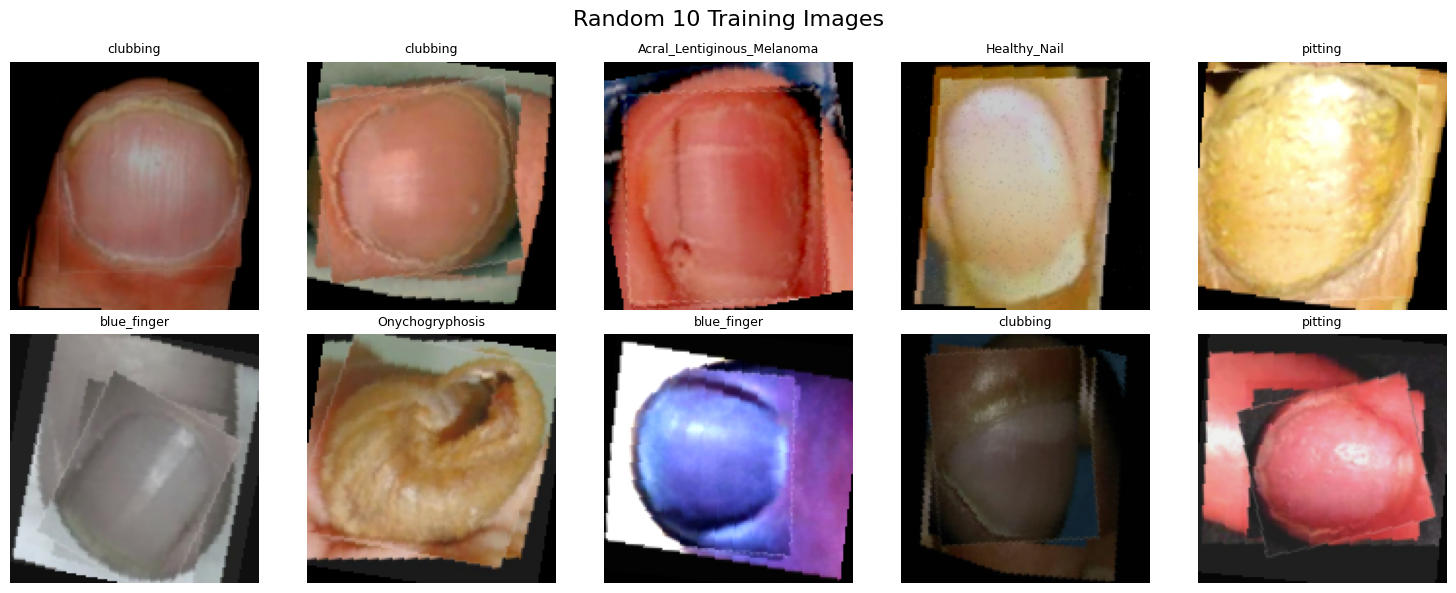

In [97]:
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

indices = random.sample(range(len(train_data)), 10)

for i, idx in enumerate(indices):
    image, label = train_data[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(base_dataset.classes[label], fontsize=9)
    plt.axis("off")

plt.suptitle("Random 10 Training Images", fontsize=16)
plt.tight_layout()
plt.show()

# 4.1 Model

In [104]:
batch_size = 32
learning_rate=0.001
minimum_learning_rate=1e-4
epochs = 50

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,num_workers=2, pin_memory=True)
val_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

In [105]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3)
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
           nn.Linear(256, len(train_dataset.classes))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

#1. Get the Model
model = CNNModel().to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3,size,size));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

5. Training Loop with validation

In [106]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        # compute accuracy
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total

    return train_loss, train_acc

def validate_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total

    return val_loss, val_acc

In [107]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

----------------------------------------------------
Epoch 1/50, LR: 0.001
Train Loss: 1.6438 | Train Acc: 0.3241
Val Loss: 1.6730 | Val Acc: 0.2880
----------------------------------------------------
Epoch 2/50, LR: 0.000999112
Train Loss: 1.5235 | Train Acc: 0.3770
Val Loss: 1.4633 | Val Acc: 0.3947
----------------------------------------------------
Epoch 3/50, LR: 0.000996452
Train Loss: 1.4938 | Train Acc: 0.3868
Val Loss: 1.4202 | Val Acc: 0.4347
----------------------------------------------------
Epoch 4/50, LR: 0.000992029
Train Loss: 1.4227 | Train Acc: 0.4233
Val Loss: 1.9014 | Val Acc: 0.3360
----------------------------------------------------
Epoch 5/50, LR: 0.000985862
Train Loss: 1.3955 | Train Acc: 0.4408
Val Loss: 1.4772 | Val Acc: 0.3840
----------------------------------------------------
Epoch 6/50, LR: 0.000977975
Train Loss: 1.3248 | Train Acc: 0.4663
Val Loss: 1.2368 | Val Acc: 0.4800
----------------------------------------------------
Epoch 7/50, LR: 0.00096

In [109]:
torch.save(model.state_dict(), "CNN_23_50647.pth")
print("Model saved successfully!")

Model saved successfully!


**6. Evaluate model on test**

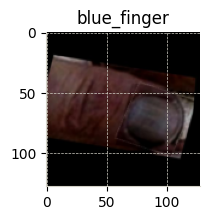

In [111]:
model.eval()
with torch.no_grad():
  ix = torch.randint(0,len(test_data),())
  img = test_data[ix][0].unsqueeze(0).to(device)
  np_output = model(img).cpu().detach().numpy()
  pred = np.exp(np_output)/np.sum(np.exp(np_output))
  plt.figure(figsize=(2,2))
  plt.imshow(img.squeeze(0).permute(1,2,0).cpu().detach().numpy())
  plt.title(train_dataset.classes[pred[0].argmax()])
  plt.show()

Total Misclassified Images: 97


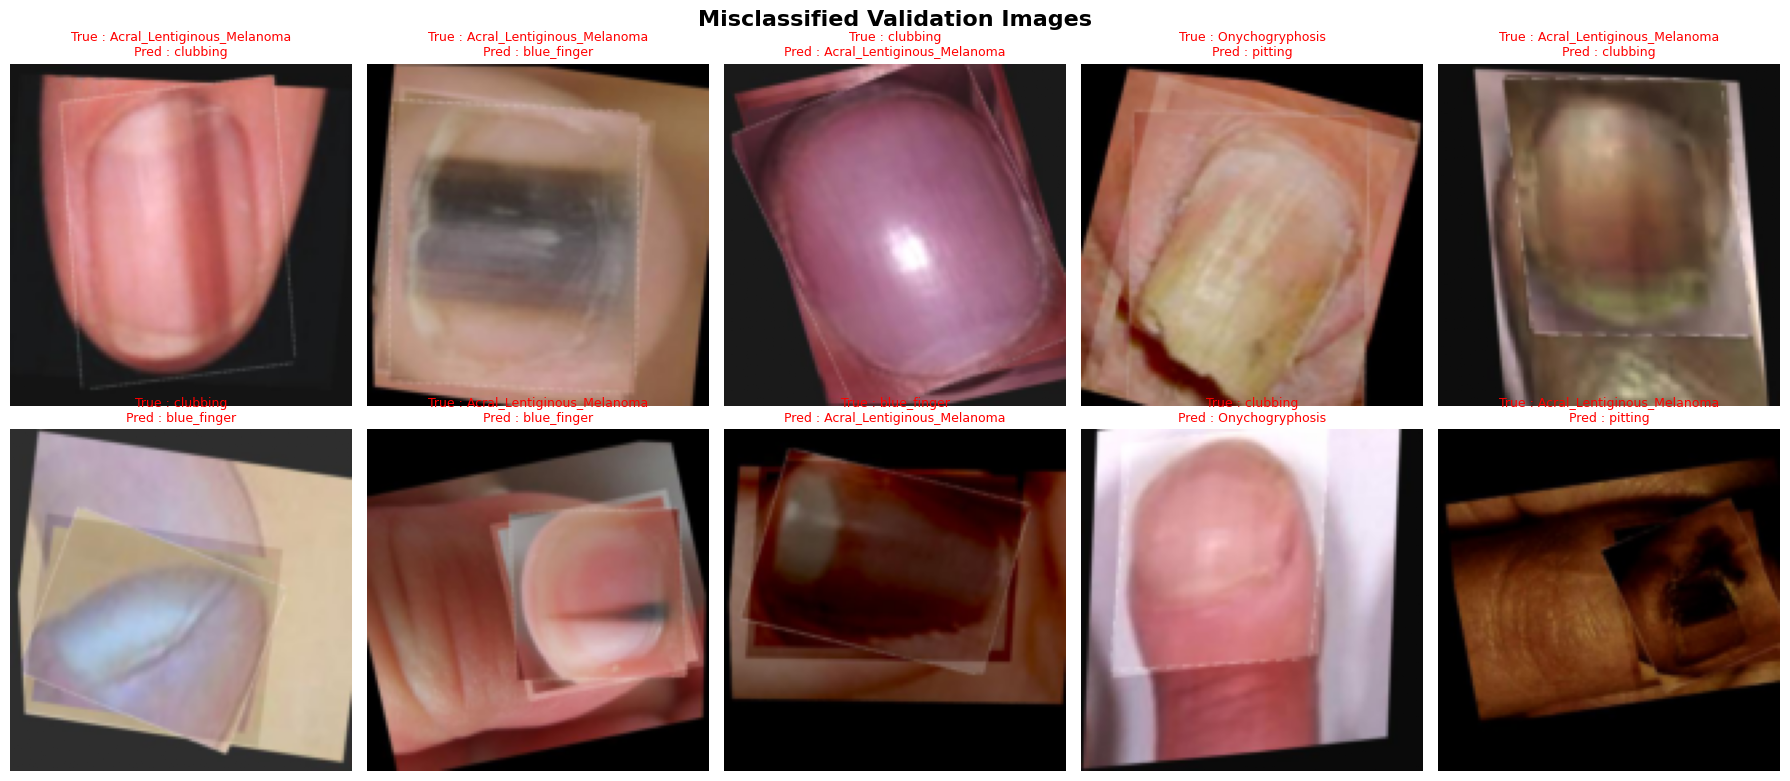

In [113]:
import matplotlib.pyplot as plt

# Store all misclassified samples
misclassified = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu().item(), pred.cpu().item()))

print(f"Total Misclassified Images: {len(misclassified)}")

# Display first 10 misclassified images
num_images = min(10, len(misclassified))

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i in range(num_images):

    img, true_label, pred_label = misclassified[i]

    img = img.permute(1, 2, 0)

    axes[i].imshow(img)

    axes[i].set_title(
        f"True : {class_names[true_label]}\nPred : {class_names[pred_label]}",
        fontsize=9,
        color="red"
    )

    axes[i].axis("off")

    # Red border
    for spine in axes[i].spines.values():
        spine.set_edgecolor("red")
        spine.set_linewidth(2)

# Hide unused plots
for i in range(num_images, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Misclassified Validation Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

7. 7. Visualizations (Loss/Accuracy Curves, Confusion Matrix)

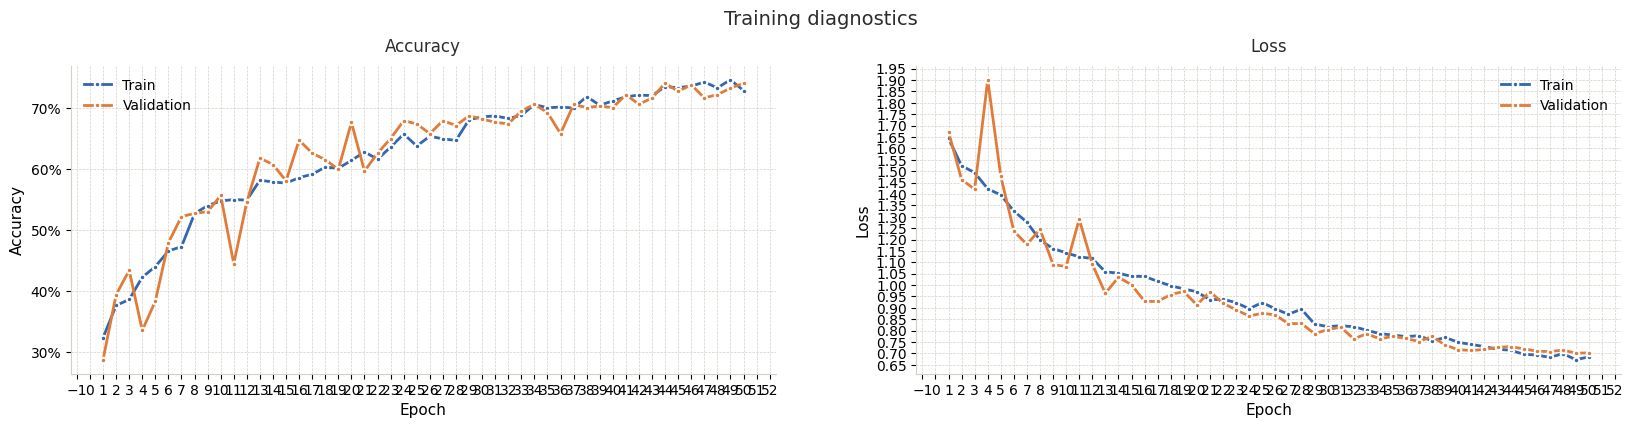

In [120]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np

BLUE   = "#3266ad"
ORANGE = "#e07b39"
GRAY   = "#88877f"
BLACK  = "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_number = np.arange(1, epochs+1)
fig = plt.figure(figsize=(20, 4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.2)


# ── Accuracy ──────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_number, train_accuracies, color=BLUE,   lw=2,   label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax1.plot(epochs_number, val_accuracies,   color=ORANGE, lw=2,   label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax1.set_ylabel("Accuracy", color=BLACK, fontsize=11)
ax1.set_title("Accuracy", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax1.legend(frameon=False, fontsize=10, labelcolor=BLACK)

# ── Loss ──────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_number, train_losses, color=BLUE,   lw=2, label="Train",      marker="o", ms=4, mew=1.5, mec="white")
ax2.plot(epochs_number, val_losses,   color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mew=1.5, mec="white", linestyle="-")
ax2.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax2.set_xlabel("Epoch", color=BLACK, fontsize=11)
ax2.set_ylabel("Loss",  color=BLACK, fontsize=11)
ax2.set_title("Loss", fontsize=12, fontweight="medium", color="#2c2c2a", pad=10)
ax2.legend(frameon=False, fontsize=10, labelcolor=BLACK)

fig.suptitle("Training diagnostics", fontsize=14, fontweight="medium", color="#2c2c2a", y=1.02)
plt.savefig("training_curves.pdf", bbox_inches="tight", dpi=150)
plt.show()



In [121]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

                            precision    recall  f1-score   support

Acral_Lentiginous_Melanoma       0.86      0.67      0.75        18
              Healthy_Nail       1.00      0.95      0.97        20
           Onychogryphosis       0.56      0.83      0.67        12
               blue_finger       0.88      0.78      0.82         9
                  clubbing       0.92      0.75      0.83        16
                   pitting       0.79      0.94      0.86        16

                  accuracy                           0.82        91
                 macro avg       0.83      0.82      0.82        91
              weighted avg       0.85      0.82      0.83        91



In [122]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

class_names = train_dataset.classes  # Corrected: Get class names from train_dataset

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # Save all predictions and labels for confusion matrix
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Store misclassified images
        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

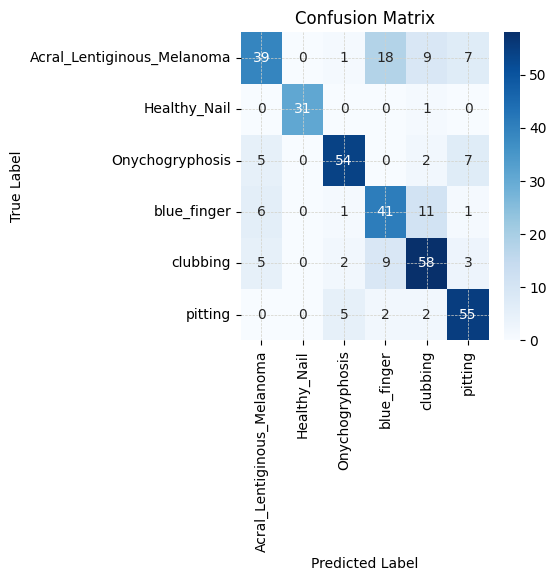

In [124]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# **8. Analysis & Discussion of Results**


# **9.  Conclusions & Future Work**
